=== 1. 数据读取和基本信息 ===
数据形状: (1470, 35)
数据前5行:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfact

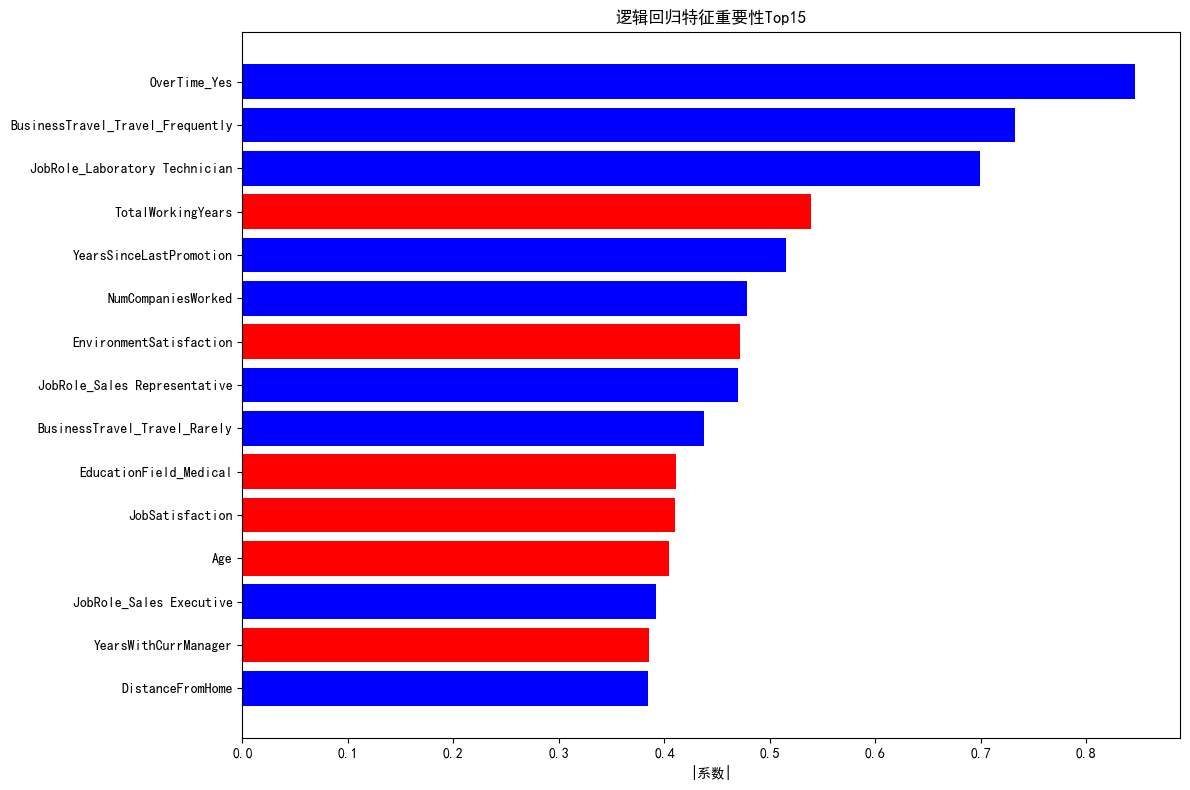


=== 6. 统计显著性分析 ===
         Current function value: 0.283550
         Iterations: 35
逻辑回归统计摘要:
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1176
Model:                          Logit   Df Residuals:                     1131
Method:                           MLE   Df Model:                           44
Date:                Wed, 20 Aug 2025   Pseudo R-squ.:                  0.3589
Time:                        17:18:32   Log-Likelihood:                -333.45
converged:                      False   LL-Null:                       -520.09
Covariance Type:            nonrobust   LLR p-value:                 9.518e-54
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8651    167.583     -0.017      0.986    -331.321     325.591
x1            -0.4097      0.149   

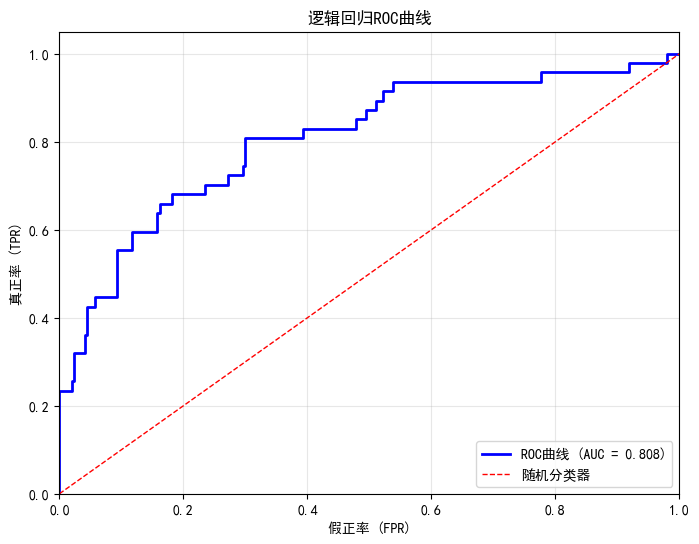


=== 9. 模型诊断和残差分析 ===


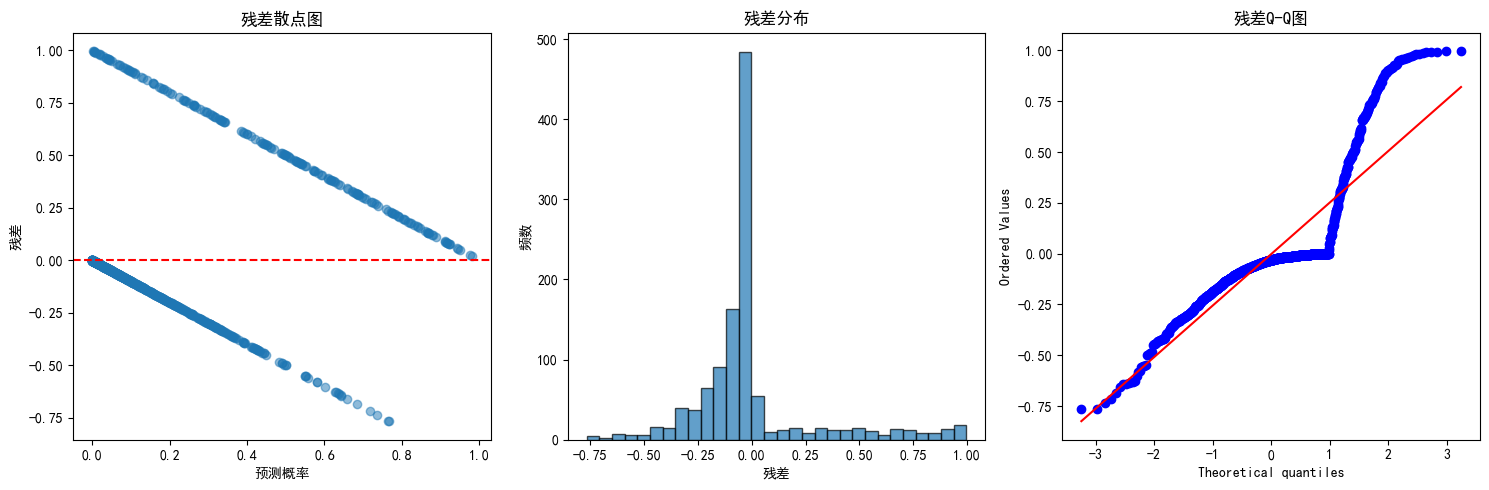


=== 10. 结果总结和解释 ===
=== 逻辑回归分析结果总结 ===
模型类型: 逻辑回归
训练样本数: 1176
测试样本数: 294
特征数量: 44
ROC AUC: 0.8077353777241795
准确率: 0.8605442176870748
显著特征数: 0
高VIF特征数: 0

=== 主要发现 ===
1. 最重要的预测因素:
   - OverTime_Yes: 正向影响 (系数: 0.8465)
   - BusinessTravel_Travel_Frequently: 正向影响 (系数: 0.7325)
   - JobRole_Laboratory Technician: 正向影响 (系数: 0.6992)
   - TotalWorkingYears: 负向影响 (系数: -0.5389)
   - YearsSinceLastPromotion: 正向影响 (系数: 0.5149)

3. 模型性能:
   - ROC AUC: 0.8077
   - 准确率: 0.8605

分析完成！


In [12]:
# 1. 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
try:
    plt.rcParams['font.sans-serif'] = ['SimHei']
except:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("=== 1. 数据读取和基本信息 ===")
# 读取数据
try:
    df = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
except:
    try:
        df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
    except:
        print("请检查数据文件路径")
        exit()

print("数据形状:", df.shape)
print("数据前5行:")
print(df.head())

print("\n=== 2. 数据预处理 ===")
# 检查数据类型和缺失值
print("数据类型:")
print(df.dtypes)
print("\n缺失值统计:")
print(df.isnull().sum())

# 处理目标变量
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 识别分类变量和数值变量
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 移除不需要的变量
categorical_features = [col for col in categorical_features if col != 'Attrition']
numerical_features = [col for col in numerical_features if col not in ['Attrition', 'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']]

print("分类变量:", categorical_features)
print("数值变量:", numerical_features)

# 独热编码
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# 准备特征和目标变量
columns_to_drop = ['Attrition', 'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
available_columns = [col for col in columns_to_drop if col in df_encoded.columns]

X = df_encoded.drop(available_columns, axis=1)
y = df_encoded['Attrition']

print("编码后特征数量:", X.shape[1])
print("目标变量分布:")
print(y.value_counts(normalize=True))

print("\n=== 3. 数据分割和标准化 ===")
# 分割训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 标准化数值特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("训练集形状:", X_train_scaled.shape)
print("测试集形状:", X_test_scaled.shape)
print("训练集目标变量分布:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\n=== 4. 逻辑回归模型训练 ===")
# 训练逻辑回归模型
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
lr_model.fit(X_train_scaled, y_train)

# 预测
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# 模型评估
print("分类报告:")
print(classification_report(y_test, y_pred))

print("混淆矩阵:")
print(confusion_matrix(y_test, y_pred))

print("ROC AUC分数:", roc_auc_score(y_test, y_pred_proba))

print("\n=== 5. 特征重要性分析 ===")
# 特征重要性
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
})
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

print("特征重要性Top15:")
print(feature_importance.head(15))

# 可视化特征重要性
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = ['red' if x < 0 else 'blue' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['abs_coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('|系数|')
plt.title('逻辑回归特征重要性Top15')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== 6. 统计显著性分析 ===")
# 使用statsmodels进行详细的统计分析
try:
    import statsmodels.api as sm
    
    X_train_with_const = sm.add_constant(X_train_scaled)
    model = sm.Logit(y_train, X_train_with_const)
    result = model.fit()
    
    print("逻辑回归统计摘要:")
    print(result.summary())
    
    # 提取p值和置信区间
    summary_table = result.summary().tables[1]
    summary_df = pd.read_html(summary_table.as_html(), header=0, index_col=0)[0]
    
    # 添加特征名称
    summary_df.index = ['常数项'] + list(X.columns)
    
    print("\n显著性分析结果:")
    significant_features = summary_df[summary_df['P>|z|'] < 0.05]
    print(f"显著特征数量: {len(significant_features)}")
    print("\n显著特征:")
    print(significant_features[['coef', 'P>|z|']])
    
except Exception as e:
    print(f"统计显著性分析出错: {e}")
    significant_features = pd.DataFrame()

print("\n=== 7. 多重共线性检验 ===")
# 计算VIF（方差膨胀因子）
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    def calculate_vif(X):
        vif_data = pd.DataFrame()
        vif_data["Variable"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        return vif_data.sort_values('VIF', ascending=False)
    
    vif_results = calculate_vif(X_train_scaled)
    print("VIF分析结果:")
    print(vif_results)
    
    # 识别高VIF的特征
    high_vif_features = vif_results[vif_results['VIF'] > 5]
    print(f"\n高VIF特征 (VIF > 5): {len(high_vif_features)}")
    if len(high_vif_features) > 0:
        print(high_vif_features)
        
except Exception as e:
    print(f"多重共线性检验出错: {e}")
    high_vif_features = pd.DataFrame()

print("\n=== 8. ROC曲线分析 ===")
# 绘制ROC曲线
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC曲线 (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--', label='随机分类器')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正率 (FPR)')
plt.ylabel('真正率 (TPR)')
plt.title('逻辑回归ROC曲线')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== 9. 模型诊断和残差分析 ===")
# 计算预测概率
train_pred_proba = lr_model.predict_proba(X_train_scaled)[:, 1]

# 残差分析
residuals = y_train - train_pred_proba

plt.figure(figsize=(15, 5))

# 残差散点图
plt.subplot(1, 3, 1)
plt.scatter(train_pred_proba, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('预测概率')
plt.ylabel('残差')
plt.title('残差散点图')

# 残差直方图
plt.subplot(1, 3, 2)
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('残差')
plt.ylabel('频数')
plt.title('残差分布')

# Q-Q图
plt.subplot(1, 3, 3)
try:
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('残差Q-Q图')
except:
    plt.text(0.5, 0.5, 'Q-Q图生成失败', ha='center', va='center')
    plt.title('残差Q-Q图')

plt.tight_layout()
plt.show()

print("\n=== 10. 结果总结和解释 ===")
# 创建结果总结
results_summary = {
    '模型类型': '逻辑回归',
    '训练样本数': len(X_train),
    '测试样本数': len(X_test),
    '特征数量': X.shape[1],
    'ROC AUC': roc_auc_score(y_test, y_pred_proba),
    '准确率': (y_pred == y_test).mean(),
    '显著特征数': len(significant_features) if not significant_features.empty else 0,
    '高VIF特征数': len(high_vif_features) if not high_vif_features.empty else 0
}

print("=== 逻辑回归分析结果总结 ===")
for key, value in results_summary.items():
    print(f"{key}: {value}")

print("\n=== 主要发现 ===")
print("1. 最重要的预测因素:")
for i, row in feature_importance.head(5).iterrows():
    direction = "正向" if row['coefficient'] > 0 else "负向"
    print(f"   - {row['feature']}: {direction}影响 (系数: {row['coefficient']:.4f})")

if not significant_features.empty:
    print("\n2. 统计显著的特征:")
    for feature in significant_features.index[:5]:
        if feature != '常数项':
            p_value = significant_features.loc[feature, 'P>|z|']
            coef = significant_features.loc[feature, 'coef']
            print(f"   - {feature}: p值={p_value:.4f}, 系数={coef:.4f}")

print("\n3. 模型性能:")
print(f"   - ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"   - 准确率: {(y_pred == y_test).mean():.4f}")

print("\n分析完成！")

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def logistic_regression_analysis():
    # 读取数据
    df = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
    
    # 独热编码
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()
    df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
    
    # 准备特征和目标变量
    columns_to_drop = ['Attrition', 'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
    available_columns = [col for col in columns_to_drop if col in df_encoded.columns]
    X = df_encoded.drop(available_columns, axis=1)
    y = df_encoded['Attrition']
    
    # 特征中文映射
    feature_mapping = {
        'Age': '年龄', 'DailyRate': '日薪', 'DistanceFromHome': '离家距离', 'Education': '教育水平',
        'EnvironmentSatisfaction': '环境满意度', 'HourlyRate': '时薪', 'JobInvolvement': '工作参与度',
        'JobLevel': '工作级别', 'JobSatisfaction': '工作满意度', 'MonthlyIncome': '月收入',
        'MonthlyRate': '月费率', 'NumCompaniesWorked': '工作公司数', 'OverTime': '加班',
        'PercentSalaryHike': '薪资涨幅百分比', 'PerformanceRating': '绩效评级',
        'RelationshipSatisfaction': '关系满意度', 'StockOptionLevel': '股票期权级别',
        'TotalWorkingYears': '总工作年限', 'TrainingTimesLastYear': '去年培训次数',
        'WorkLifeBalance': '工作生活平衡', 'YearsAtCompany': '在公司年限',
        'YearsInCurrentRole': '当前职位年限', 'YearsSinceLastPromotion': '上次晋升年限',
        'YearsWithCurrManager': '与当前经理共事年限', 'BusinessTravel_Travel_Frequently': '商务旅行_频繁',
        'BusinessTravel_Travel_Rarely': '商务旅行_很少', 'Department_Research & Development': '部门_研发',
        'Department_Sales': '部门_销售', 'EducationField_Human Resources': '教育领域_人力资源',
        'EducationField_Life Sciences': '教育领域_生命科学', 'EducationField_Marketing': '教育领域_市场营销',
        'EducationField_Medical': '教育领域_医学', 'EducationField_Other': '教育领域_其他',
        'EducationField_Technical Degree': '教育领域_技术学位', 'Gender_Male': '性别_男性',
        'JobRole_Healthcare Representative': '工作角色_医疗代表', 'JobRole_Human Resources': '工作角色_人力资源',
        'JobRole_Laboratory Technician': '工作角色_实验室技术员', 'JobRole_Manager': '工作角色_经理',
        'JobRole_Manufacturing Director': '工作角色_制造总监', 'JobRole_Research Director': '工作角色_研究总监',
        'JobRole_Research Scientist': '工作角色_研究科学家', 'JobRole_Sales Executive': '工作角色_销售主管',
        'JobRole_Sales Representative': '工作角色_销售代表', 'MaritalStatus_Divorced': '婚姻状况_离异',
        'MaritalStatus_Married': '婚姻状况_已婚', 'MaritalStatus_Single': '婚姻状况_单身'
    }
    
    # 重命名特征为中文
    X.columns = [feature_mapping.get(col, col) for col in X.columns]
    
    # 数据分割和标准化
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # 逻辑回归分析
    X_train_with_const = sm.add_constant(X_train_scaled)
    model = sm.Logit(y_train, X_train_with_const)
    result = model.fit()
    
    # 提取统计结果
    summary_data = []
    feature_names = ['常数项'] + list(X.columns)
    
    for i, feature in enumerate(feature_names):
        if i == 0:
            coef = result.params[0]
            std_err = result.bse[0]
            z_value = result.tvalues[0]
            p_value = result.pvalues[0]
            ci_lower = result.conf_int().iloc[0, 0]
            ci_upper = result.conf_int().iloc[0, 1]
        else:
            coef = result.params[i]
            std_err = result.bse[i]
            z_value = result.tvalues[i]
            p_value = result.pvalues[i]
            ci_lower = result.conf_int().iloc[i, 0]
            ci_upper = result.conf_int().iloc[i, 1]
        
        summary_data.append({
            '特征': feature,
            '系数': coef,
            '标准误': std_err,
            'Z值': z_value,
            'P值': p_value,
            '置信区间下限': ci_lower,
            '置信区间上限': ci_upper
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df.set_index('特征', inplace=True)
    
    # 添加优势比
    summary_df['优势比'] = np.exp(summary_df['系数'])
    
    # 添加显著性标记
    summary_df['显著性'] = summary_df['P值'].apply(lambda x: '***' if x < 0.001 else '**' if x < 0.01 else '*' if x < 0.05 else '')
    
    return summary_df

# 调用函数获取结果表
result_table = logistic_regression_analysis()
print(result_table)

         Current function value: 0.283550
         Iterations: 35
                    系数           标准误        Z值            P值        置信区间下限  \
特征                                                                           
常数项          -2.865104    167.582574 -0.017097  9.863595e-01   -331.320913   
年龄           -0.409718      0.148751 -2.754381  5.880333e-03     -0.701265   
日薪           -0.190713      0.101731 -1.874670  6.083814e-02     -0.390103   
离家距离          0.405745      0.100042  4.055756  4.997231e-05      0.209667   
教育水平          0.015534      0.102244  0.151929  8.792428e-01     -0.184861   
环境满意度        -0.498949      0.103246 -4.832625  1.347443e-06     -0.701307   
时薪           -0.007636      0.102017 -0.074849  9.403352e-01     -0.207585   
工作参与度        -0.368750      0.098820 -3.731540  1.903132e-04     -0.562432   
工作级别          0.362275      0.391575  0.925175  3.548748e-01     -0.405197   
工作满意度        -0.427674      0.101883 -4.197709  2.696291e-05     -0.627360  